In [1]:
import pandas as pd

In [5]:
df = pd.read_csv("/content/tweetminiproject/data_science.csv",
                 low_memory=False,
                 on_bad_lines='skip')  # skip rows causing errors

df.head()

,id,conversation_id,created_at,date,time,timezone,user_id,username,name,place,...,geo,source,user_rt_id,user_rt,retweet_id,reply_to,retweet_date,translate,trans_src,trans_dest
0,1406400408545804288,1406400396264943616,2021-06-20 05:26:01 IST,2021-06-20,05:26:01,530,1113747629282930688,ballouxfrancois,Prof Francois Balloux,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
1,1406390341176016897,1406390341176016897,2021-06-20 04:46:01 IST,2021-06-20,04:46:01,530,788898706586275840,tdatascience,Towards Data Science,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
2,1406386311481774083,1406386311481774083,2021-06-20 04:30:00 IST,2021-06-20,04:30:00,530,19402238,sciencenews,Science News,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
3,1406383545153638402,1406383545153638402,2021-06-20 04:19:01 IST,2021-06-20,04:19:01,530,788898706586275840,tdatascience,Towards Data Science,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN
4,1406358632648818689,1406358632648818689,2021-06-20 02:40:01 IST,2021-06-20,02:40:01,530,788898706586275840,tdatascience,Towards Data Science,NaN,...,NaN,NaN,NaN,NaN,NaN,[],NaN,NaN,NaN,NaN


In [6]:
df.columns

Index(['id', 'conversation_id', 'created_at', 'date', 'time', 'timezone',
       'user_id', 'username', 'name', 'place', 'tweet', 'language', 'mentions',
       'urls', 'photos', 'replies_count', 'retweets_count', 'likes_count',
       'hashtags', 'cashtags', 'link', 'retweet', 'quote_url', 'video',
       'thumbnail', 'near', 'geo', 'source', 'user_rt_id', 'user_rt',
       'retweet_id', 'reply_to', 'retweet_date', 'translate', 'trans_src',
       'trans_dest'],
      dtype='object')

In [7]:
# Check number of rows and columns
print("Rows, Columns:", df.shape)

Rows, Columns: (241386, 36)


In [8]:
# Check info about data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241386 entries, 0 to 241385
Data columns (total 36 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               241386 non-null  int64  
 1   conversation_id  241386 non-null  int64  
 2   created_at       241386 non-null  object 
 3   date             241386 non-null  object 
 4   time             241386 non-null  object 
 5   timezone         241386 non-null  int64  
 6   user_id          241386 non-null  int64  
 7   username         241386 non-null  object 
 8   name             241386 non-null  object 
 9   place            354 non-null     object 
 10  tweet            241386 non-null  object 
 11  language         241386 non-null  object 
 12  mentions         241386 non-null  object 
 13  urls             241386 non-null  object 
 14  photos           241386 non-null  object 
 15  replies_count    241386 non-null  int64  
 16  retweets_count   241386 non-null  int6

In [9]:
# Check basic statistics
df.describe()

,id,conversation_id,timezone,user_id,replies_count,retweets_count,likes_count,video,near,geo,source,user_rt_id,user_rt,retweet_id,retweet_date,translate,trans_src,trans_dest
count,2.413860e+05,2.413860e+05,241386.0,2.413860e+05,241386.000000,241386.000000,241386.000000,241386.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,9.529281e+17,9.528276e+17,530.0,2.346056e+16,1.356678,11.569076,27.964269,0.457102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,3.104049e+17,3.103971e+17,0.0,1.442948e+17,34.724170,140.701341,751.545541,0.498157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,7.333963e+09,7.333963e+09,530.0,1.300000e+01,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,7.326473e+17,7.325960e+17,530.0,3.691232e+07,0.000000,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,9.975409e+17,9.974605e+17,530.0,3.547840e+08,0.000000,3.000000,4.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.216005e+18,1.215739e+18,530.0,5.345640e+08,0.000000,9.000000,12.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,1.406400e+18,1.406400e+18,530.0,1.378437e+18,5769.000000,24505.000000,150746.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
import re

# Function to clean tweets
def clean_text(text):
    text = re.sub(r'http\S+', '', str(text))  # remove URLs
    text = re.sub(r'@\w+', '', text)          # remove mentions
    text = re.sub(r'#', '', text)             # remove hashtags
    text = re.sub(r'\n', ' ', text)           # remove newlines
    return text

# Apply cleaning
df['clean_text'] = df['tweet'].apply(clean_text)
df[['tweet', 'clean_text']].head()

,tweet,clean_text
0,What can be done? - Never blindly trust an ab...,What can be done? - Never blindly trust an ab...
1,"""We need a paradigm shift from model-centric t...","""We need a paradigm shift from model-centric t..."
2,Using high-resolution satellite data and compu...,Using high-resolution satellite data and compu...
3,.@Stephenson_Data shares four steps that will ...,. shares four steps that will help new data sc...
4,"""Curricula is inherently brittle in a world wh...","""Curricula is inherently brittle in a world wh..."


In [12]:
# Install TextBlob
!pip install textblob

In [13]:
from textblob import TextBlob

In [14]:
# Function to classify sentiment
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return "Positive"
    else:
        return "Negative"


In [15]:

# Apply function to dataframe
df['sentiment'] = df['clean_text'].apply(get_sentiment)
df[['clean_text', 'sentiment']].head(10)

,clean_text,sentiment
0,What can be done? - Never blindly trust an ab...,Positive
1,"""We need a paradigm shift from model-centric t...",Negative
2,Using high-resolution satellite data and compu...,Negative
3,. shares four steps that will help new data sc...,Positive
4,"""Curricula is inherently brittle in a world wh...",Positive
5,Many common colour maps distort data through u...,Positive
6,Wow! Wonderful!! Congratulations and thank y...,Positive
7,Register now and build your HPEDiscover 2021 A...,Negative
8,What is ModelOps vs. MLOps? “ModelOps is key t...,Negative
9,Demystifying AI with 10 top applications: ——...,Positive


In [16]:
# Count positive vs negative
df['sentiment'].value_counts()

,count
sentiment,
Negative,130281
Positive,111105


In [17]:
import matplotlib.pyplot as plt

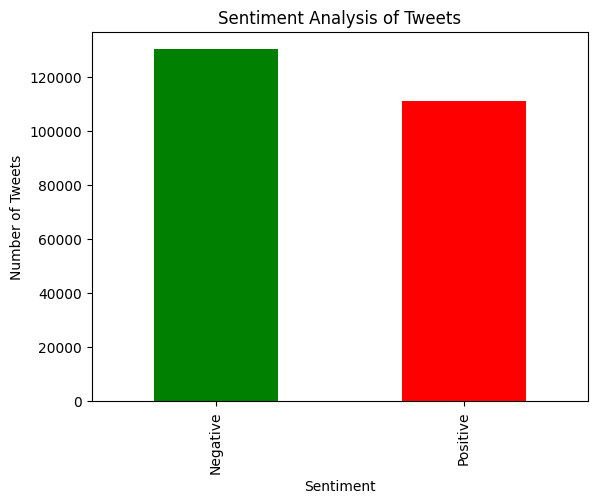

In [18]:
df['sentiment'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title("Sentiment Analysis of Tweets")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

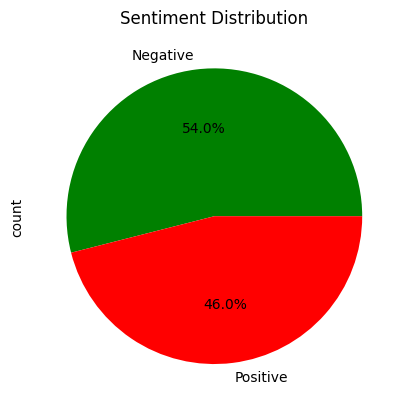

In [19]:
df['sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['green','red'])
plt.title("Sentiment Distribution")
plt.show()